<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<br><h1>Lunar Frame Extractor</h1>
<h4>Frame Extraction and Spike Filtering</h4>
Chase Kusterer<br>
Northwestern University<br><br><br>

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Preparation</h2>

Imports, reproducibility, device, and the run knobs. This notebook works one clip at a time so each stage can be inspected before moving on: it scans and scores the frames, lays out the exploratory analysis, then aligns frames on their craters. Stacking is deliberately left for a later step, once the analysis below has settled the keep window.

In [ ]:
# core data + numerics
import os
import gc
import glob
import textwrap
import numpy as np
import pandas as pd

# video + image handling
import cv2
import tifffile as tiff

# plotting
import matplotlib.pyplot as plt

# progress bars
from tqdm import tqdm

# housekeeping
import warnings

warnings.filterwarnings(action = 'ignore')


# reproducibility
np.random.seed(seed = 702)

<br>

In [ ]:
## directory utilities ##

# lunar clips
lunar_dir = f'lunar_videos/*.MP4'

# which matched clip to analyze in this pass (0 = first)
clip_index = 0

# parent folder for outputs, one sub-folder per clip
output_dir = f'lunar_stack_artifacts/'

<br>

In [1]:
# ----------------------------------------------------------------------
# RUN CONFIGURATION  (the cell you normally edit)
# ----------------------------------------------------------------------

# central fraction of each frame used for scoring, so any dark border stays out of the metric
roi_keep = 0.80

# ---- exploratory analysis ----
# percentiles at which to display a representative frame
gallery_percentiles = [0, 10, 25, 50, 75, 90, 100]

# a frame is flagged a "spike" when a channel sits beyond this many standard deviations
spike_sigma = 2.0

# ---- crater-point alignment ----
# how many of the sharpest frames to align in this demonstration pass
align_sample = 15

# SIFT keypoint budget, Lowe ratio-test threshold, and the RANSAC inlier floor
sift_features = 2000
ratio_test    = 0.75
min_inliers   = 12


os.makedirs(name = output_dir, exist_ok = True)

print(f"""
Preparation
-----------
Lunar Directory   : {lunar_dir}
Clip Index        : {clip_index}
Output Dierectory : {output_dir}""")


Preparation
-----------
video_glob : Moon Videos/*.MP4
clip_index : 0
output_dir : moon_stack_audit


<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Video Ingestion</h2>

A wildcard is only a pattern, <code>cv2.VideoCapture</code> needs a real path, so we resolve <strong>lunar_dir</strong> into a concrete list and probe each clip. The clip selected by <strong>clip_index</strong> becomes the working clip for everything below.

In [2]:
# expanding the wildcard into real file paths, in sorted order
video_paths = sorted(glob.glob(pathname = lunar_dir))

if len(video_paths) == 0:
    raise FileNotFoundError(f"no clips matched: {lunar_dir}")


# probing every clip so the batch is visible, even though we work one at a time
probe_rows = []

for path in video_paths:
    probe = cv2.VideoCapture(filename = path)
    probe_rows.append({'clip'   : os.path.basename(path),
                       'frames' : int(probe.get(propId = cv2.CAP_PROP_FRAME_COUNT)),
                       'fps'    : round(probe.get(propId = cv2.CAP_PROP_FPS), 2),
                       'width'  : int(probe.get(propId = cv2.CAP_PROP_FRAME_WIDTH)),
                       'height' : int(probe.get(propId = cv2.CAP_PROP_FRAME_HEIGHT))})
    probe.release()

ingest_df = pd.DataFrame(data = probe_rows)


# fixing the working clip and its own output folder
working_path = video_paths[clip_index]
working_stem = os.path.splitext(os.path.basename(working_path))[0]
working_out  = os.path.join(output_dir, working_stem)
os.makedirs(name = working_out, exist_ok = True)

print(f"""
Video Ingestion
---------------
clips found  : {len(video_paths)}
working clip : {working_stem}
output       : {working_out}""")

ingest_df


Video Ingestion
---------------
clips found  : 5
working clip : C0136_stable_full
output       : moon_stack_audit/C0136_stable_full


,clip,frames,fps,width,height
0,C0136_stable_full.MP4,1320,59.94,1920,1080
1,C0136_stable_trim.MP4,600,59.86,1920,1080
2,C0137_wobble.MP4,1710,59.94,1920,1080
3,C0138_wobble_2.MP4,990,59.94,1920,1080
4,C0139_wobble_scan.MP4,2220,59.94,1920,1080


<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Frame Helpers, Metrics and Alignment</h2>

Frames arrive as 8-bit BGR. We convert to RGB and promote to the 0..65535 range (a clean <code>&times;257</code> scale) so metrics and later stacking live in 16-bit space. The scoring helpers read an inner region from a lightly blurred gray so grain is not mistaken for detail, and <strong>Tenengrad</strong> (Sobel gradient energy) is the ranking metric.

The alignment helpers implement the <em>craters-as-alignment-points</em> idea directly: <code>detect_crater_points</code> runs SIFT, whose keypoints settle on high-contrast lunar features (crater rims, central peaks, mare edges), and <code>align_to_reference</code> fits a similarity transform (translation + rotation + scale) from the matched points with RANSAC, then warps the frame onto the reference. <code>add_caption</code> writes an italic caption beneath each figure so every saved plot travels with its explanation.

In [3]:
# ---- io + display ----
def to_rgb16(frame_bgr):
    """converts an 8-bit BGR frame to a 16-bit RGB frame"""
    rgb = cv2.cvtColor(src = frame_bgr, code = cv2.COLOR_BGR2RGB)
    return rgb.astype(dtype = np.uint16) * 257


def to_gray8(frame_rgb16):
    """collapses a 16-bit rgb frame to an 8-bit gray, as SIFT expects"""
    gray16 = cv2.cvtColor(src = frame_rgb16, code = cv2.COLOR_RGB2GRAY)
    return (gray16 / 257.0).astype(dtype = np.uint8)


def to_display(image_16bit, low_pct = 0.5, high_pct = 99.5):
    """percentile-stretches a 16-bit image for viewing (does not alter saved data)"""
    img    = image_16bit.astype(dtype = np.float32)
    lo, hi = np.percentile(a = img, q = low_pct), np.percentile(a = img, q = high_pct)
    if hi <= lo:
        hi = lo + 1.0
    return np.clip(a = (img - lo) / (hi - lo), a_min = 0, a_max = 1)


def add_caption(fig, text, width = 120):
    """writes a wrapped italic caption beneath a figure"""
    fig.text(x = 0.5, y = -0.02, s = textwrap.fill(text = text, width = width),
             ha = 'center', va = 'top', fontsize = 10, style = 'italic', color = '#333')


def read_frames_by_index(path, wanted_indices):
    """returns {frame_index: 16-bit rgb frame} for the requested indices, in one sequential pass"""
    wanted  = set(int(i) for i in wanted_indices)
    capture = cv2.VideoCapture(filename = path)
    grabbed = {}
    index   = 0
    while wanted:
        ok, bgr = capture.read()
        if not ok:
            break
        if index in wanted:
            grabbed[index] = to_rgb16(frame_bgr = bgr)
            wanted.discard(index)
        index += 1
    capture.release()
    return grabbed


# ---- quality metrics ----
def inner_roi(frame_rgb, keep = roi_keep):
    """returns the central fraction of a frame"""
    height, width = frame_rgb.shape[:2]
    inner_h, inner_w = int(height * keep), int(width * keep)
    y_start, x_start = (height - inner_h) // 2, (width - inner_w) // 2
    return frame_rgb[y_start:y_start + inner_h, x_start:x_start + inner_w]


def gray_255(frame_rgb, blur_sigma = 1.0):
    """converts a frame's inner region to a lightly blurred 0..255 gray float"""
    core = inner_roi(frame_rgb = frame_rgb)
    gray = cv2.cvtColor(src = core, code = cv2.COLOR_RGB2GRAY).astype(dtype = np.float32) / 257.0
    if blur_sigma > 0:
        gray = cv2.GaussianBlur(src = gray, ksize = (0, 0), sigmaX = blur_sigma)
    return gray


def laplacian_variance(frame_rgb):
    """variance of the laplacian, higher on crisper frames"""
    return cv2.Laplacian(src = gray_255(frame_rgb = frame_rgb), ddepth = cv2.CV_32F).var()


def normalized_variance(frame_rgb):
    """contrast divided by brightness, so dim frames are judged fairly"""
    gray = gray_255(frame_rgb = frame_rgb)
    mean = gray.mean()
    return gray.var() / (mean * mean + 1e-6)


def tenengrad_variance(frame_rgb):
    """variance of the sobel gradient energy, the ranking metric"""
    gray   = gray_255(frame_rgb = frame_rgb)
    grad_x = cv2.Sobel(src = gray, ddepth = cv2.CV_32F, dx = 1, dy = 0, ksize = 3)
    grad_y = cv2.Sobel(src = gray, ddepth = cv2.CV_32F, dx = 0, dy = 1, ksize = 3)
    energy = grad_x * grad_x + grad_y * grad_y
    return energy.var()


# ---- crater-point alignment ----
def detect_crater_points(frame_rgb, max_points = sift_features):
    """returns SIFT keypoints + descriptors, which land on crater rims and other lunar features

    PARAMETERS
    ----------
    frame_rgb | np.ndarray
    a 16-bit (h, w, 3) rgb frame

    max_points | int
    the SIFT keypoint budget

    EXAMPLES
    --------
    kps, desc, gray = detect_crater_points(frame_rgb = reference)\
    """
    gray        = to_gray8(frame_rgb16 = frame_rgb)
    sift        = cv2.SIFT_create(nfeatures = max_points)
    kps, desc   = sift.detectAndCompute(image = gray, mask = None)
    return kps, desc, gray


def align_to_reference(frame_rgb, ref_kps, ref_desc, matcher):
    """aligns one frame onto the reference using matched crater points (translation + rotation + scale)

    PARAMETERS
    ----------
    frame_rgb | np.ndarray
    a 16-bit (h, w, 3) rgb frame to align

    ref_kps, ref_desc | SIFT keypoints and descriptors of the reference

    matcher | cv2.BFMatcher
    a brute-force matcher over SIFT descriptors

    EXAMPLES
    --------
    warped, stats = align_to_reference(frame_rgb = frame, ref_kps = rk, ref_desc = rd, matcher = bf)\
    """
    kps, desc, _ = detect_crater_points(frame_rgb = frame_rgb)

    if desc is None or len(kps) < min_inliers:
        return None, {'ok': False, 'good': 0, 'inliers': 0, 'angle': np.nan, 'scale': np.nan}

    # Lowe ratio test keeps only confident crater matches
    knn  = matcher.knnMatch(queryDescriptors = desc, trainDescriptors = ref_desc, k = 2)
    good = [m for m, n in knn if m.distance < ratio_test * n.distance]

    if len(good) < min_inliers:
        return None, {'ok': False, 'good': len(good), 'inliers': 0, 'angle': np.nan, 'scale': np.nan}

    src = np.float32([kps[m.queryIdx].pt     for m in good]).reshape(-1, 1, 2)
    dst = np.float32([ref_kps[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    # RANSAC fits a similarity transform and rejects mismatched points
    matrix, inliers = cv2.estimateAffinePartial2D(from_ = src, to = dst,
                                                  method = cv2.RANSAC, ransacReprojThreshold = 3.0)

    if matrix is None:
        return None, {'ok': False, 'good': len(good), 'inliers': 0, 'angle': np.nan, 'scale': np.nan}

    angle = np.degrees(np.arctan2(matrix[0, 1], matrix[0, 0]))
    scale = float(np.hypot(matrix[0, 0], matrix[0, 1]))

    warped = cv2.warpAffine(src   = frame_rgb.astype(np.float32),
                            M     = matrix,
                            dsize = (frame_rgb.shape[1], frame_rgb.shape[0]),
                            flags = cv2.INTER_CUBIC)

    stats = {'ok': True, 'good': len(good), 'inliers': int(inliers.sum()),
             'angle': angle, 'scale': scale}
    return warped, stats

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Frame Scan and Quality Scoring</h2>

One sequential pass over the working clip. For every frame we record its mean <strong>R / G / B</strong> and all three sharpness scores, holding only scalars in memory. <strong>frame_df</strong> keeps capture order for the exposure analysis, and <strong>quality_df</strong> is the same data ranked sharpest first with a percentile column.

In [4]:
# scanning the working clip once, scoring every frame
probe       = cv2.VideoCapture(filename = working_path)
frame_total = int(probe.get(propId = cv2.CAP_PROP_FRAME_COUNT))
probe.release()

scan_capture = cv2.VideoCapture(filename = working_path)
scan_rows    = []
frame_index  = 0

with tqdm(total = frame_total, desc = f'{working_stem}: scanning') as progress:
    while True:
        ok, bgr = scan_capture.read()
        if not ok:
            break
        frame_rgb = to_rgb16(frame_bgr = bgr)
        scan_rows.append({'frame_index' : frame_index,
                          'red'         : float(frame_rgb[..., 0].mean()),
                          'green'       : float(frame_rgb[..., 1].mean()),
                          'blue'        : float(frame_rgb[..., 2].mean()),
                          'laplacian'   : laplacian_variance(frame_rgb = frame_rgb),
                          'normalized'  : normalized_variance(frame_rgb = frame_rgb),
                          'tenengrad'   : tenengrad_variance(frame_rgb = frame_rgb)})
        frame_index += 1
        progress.update(n = 1)
scan_capture.release()

frame_df   = pd.DataFrame(data = scan_rows)
quality_df = frame_df.sort_values(by = 'tenengrad', ascending = False).reset_index(drop = True)
quality_df['percentile'] = quality_df['tenengrad'].rank(pct = True) * 100

print(f"""
Frame Scan
----------
frames        : {len(frame_df)}
tenengrad max : {quality_df['tenengrad'].max():.1f}
tenengrad min : {quality_df['tenengrad'].min():.1f}
median        : {quality_df['tenengrad'].median():.1f}""")

quality_df.head(n = 8)

C0136_stable_full: scanning: 100%|██████████| 1320/1320 [00:30<00:00, 43.27it/s]


Frame Scan
----------
frames        : 1320
tenengrad max : 55827980.0
tenengrad min : 9236580.0
median        : 40361060.0


,frame_index,red,green,blue,laplacian,normalized,tenengrad,percentile
0,39,5105.884043,5087.382919,5110.076033,3.923845,4.321393,55827980.0,100.000000
1,5,5106.634618,5089.155743,5115.074991,3.799256,4.291943,54833576.0,99.924242
2,40,5107.210563,5088.192488,5111.711409,3.812388,4.320217,54808748.0,99.848485
3,24,5112.169860,5093.317492,5122.056601,3.920315,4.293238,54710392.0,99.772727
4,38,5102.569913,5084.499973,5106.592727,3.868280,4.324125,54656232.0,99.696970
5,41,5105.729987,5087.095380,5110.465326,3.807403,4.321872,54455340.0,99.621212
6,64,5107.684010,5088.400458,5114.137764,3.630656,4.319819,54184876.0,99.545455
7,63,5101.911425,5083.556920,5106.838622,3.599781,4.325226,54062704.0,99.469697


<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h1>Exploratory Analysis</h1>

Three views of the clip before any stacking decision: the per-channel exposure trace (to find stable windows and flag transient spikes), the sorted sharpness curve (to choose how many frames are worth keeping), and a percentile gallery (to see what the sharpness metric is actually separating). Every figure carries a title and an italic caption.

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h3>Red, Green and Blue Across the Clip</h3>

Each channel's mean plotted in capture order. The solid line is the channel median, the shaded bands are <strong>&plusmn;1&sigma;</strong> (inner) and <strong>&plusmn;2&sigma;</strong> (outer). Frames whose value leaves the &plusmn;2&sigma; band are marked and labelled as <strong>spikes</strong>. The point of the bands is practical: a run of frames sitting inside &plusmn;1&sigma; on all three channels is a <em>flat window</em> of steady exposure and seeing, exactly the stretch worth subsetting for lucky imaging. That flat mask is computed here and stored on <code>frame_df</code> as <code>flat_window</code>.

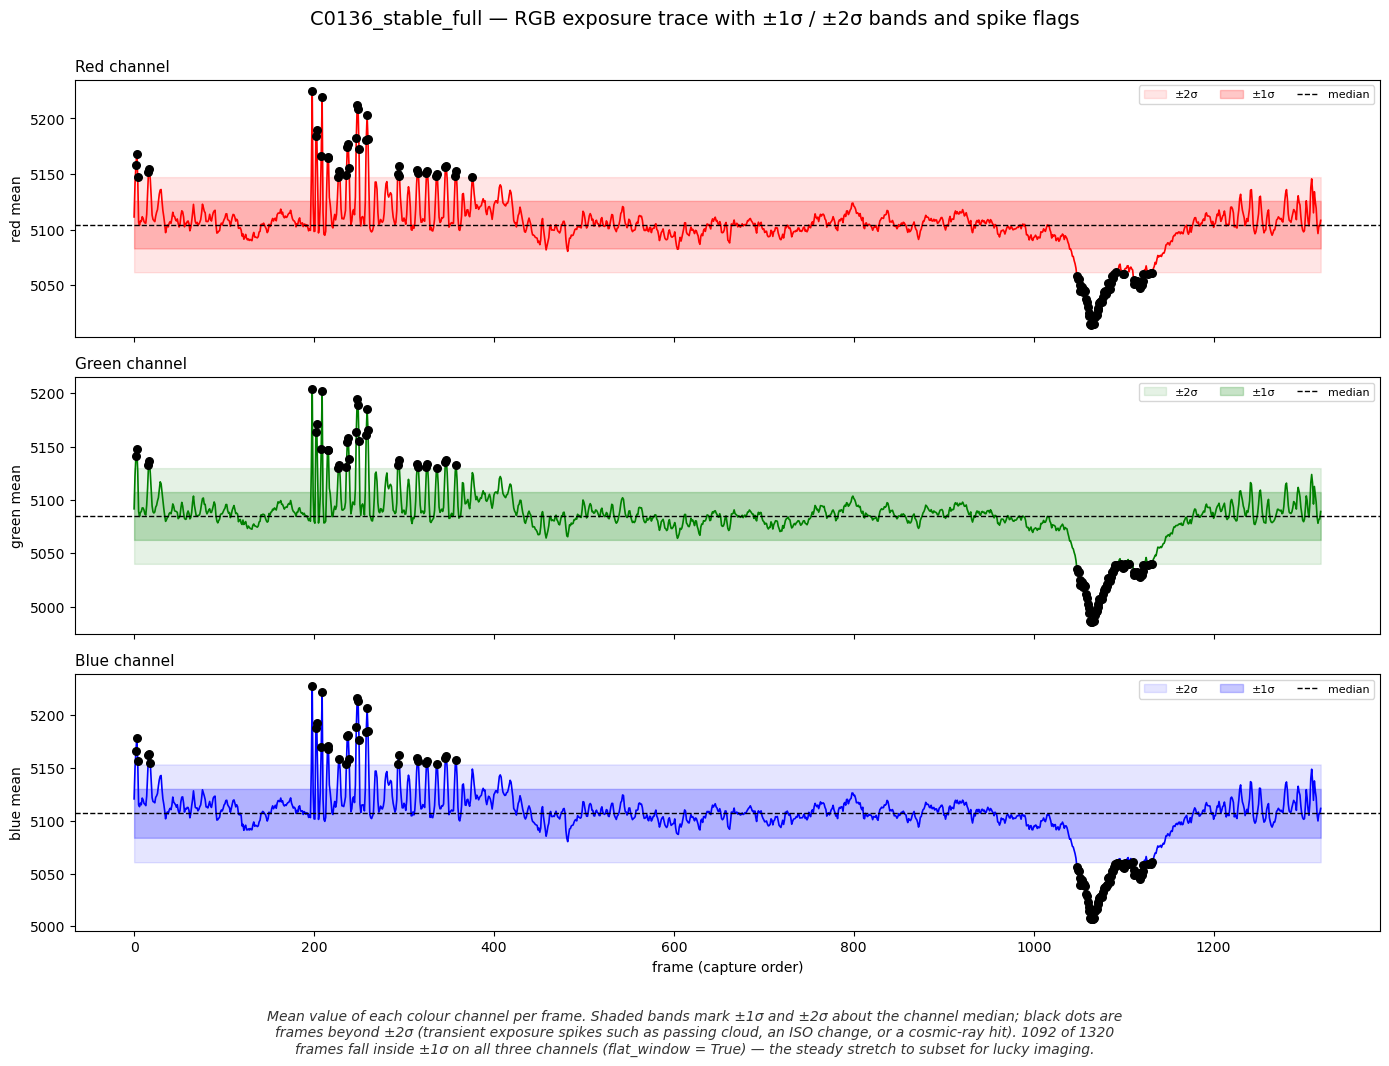

spikes flagged : 109    flat-window frames : 1092


In [5]:
# per-channel statistics and the spike / flat-window masks
channels    = ['red', 'green', 'blue']
stats       = {c: (frame_df[c].mean(), frame_df[c].std()) for c in channels}
steps       = frame_df['frame_index'].values

# a spike: any channel beyond spike_sigma; a flat frame: every channel within 1 sigma
spike_mask  = np.zeros(len(frame_df), dtype = bool)
flat_mask   = np.ones(len(frame_df),  dtype = bool)
for c in channels:
    mu, sd     = stats[c]
    deviation  = (frame_df[c] - mu).abs()
    spike_mask |= (deviation > spike_sigma * sd).values
    flat_mask  &= (deviation <= 1.0 * sd).values

frame_df['flat_window'] = flat_mask


# one stacked panel per channel, sharing the frame axis
fig, axes = plt.subplots(nrows = 3, ncols = 1, figsize = (14, 10), sharex = True)

for axis, c in zip(axes, channels):
    mu, sd = stats[c]

    axis.fill_between(x = steps, y1 = mu - 2*sd, y2 = mu + 2*sd, color = c, alpha = 0.10, label = '±2σ')
    axis.fill_between(x = steps, y1 = mu - 1*sd, y2 = mu + 1*sd, color = c, alpha = 0.22, label = '±1σ')
    axis.plot(steps, frame_df[c], color = c, linewidth = 1.2)
    axis.axhline(y = mu, color = 'black', linestyle = '--', linewidth = 1, label = 'median')

    # marking this channel's spikes
    ch_spikes = frame_df[(frame_df[c] - mu).abs() > spike_sigma * sd]
    axis.scatter(x = ch_spikes['frame_index'], y = ch_spikes[c], color = 'black', s = 30, zorder = 5)

    axis.set_ylabel(ylabel = f'{c} mean')
    axis.set_title(label = f'{c.capitalize()} channel', loc = 'left', fontsize = 11)
    axis.legend(loc = 'upper right', fontsize = 8, ncol = 4)

axes[-1].set_xlabel(xlabel = 'frame (capture order)')
fig.suptitle(t = f'{working_stem} — RGB exposure trace with ±1σ / ±2σ bands and spike flags', fontsize = 14)

add_caption(fig, f"Mean value of each colour channel per frame. Shaded bands mark ±1σ and ±2σ about the "
                 f"channel median; black dots are frames beyond ±{spike_sigma:.0f}σ (transient exposure spikes "
                 f"such as passing cloud, an ISO change, or a cosmic-ray hit). "
                 f"{int(flat_mask.sum())} of {len(frame_df)} frames fall inside ±1σ on all three channels "
                 f"(flat_window = True) — the steady stretch to subset for lucky imaging.")

plt.tight_layout(rect = [0, 0, 1, 0.98])
plt.savefig(fname = f'{working_out}/eda_rgb_trace.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print(f"spikes flagged : {int(spike_mask.sum())}    flat-window frames : {int(flat_mask.sum())}")

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h3>Sorted Tenengrad Distribution</h3>

The sharpness score of every frame, sorted best-to-worst. Its shape is the keep decision: a steep drop on the left means only a handful of frames carry the good seeing, a gentle slope means many frames are usable.

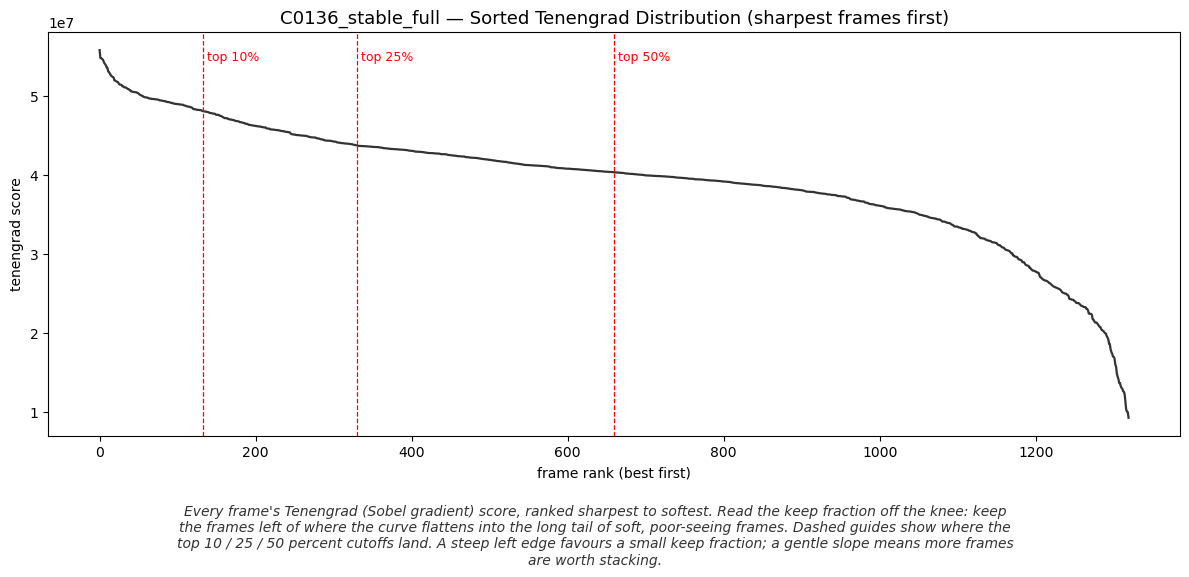

In [6]:
# the sharpness curve, sorted best first, with candidate keep cutoffs
sorted_ten = quality_df['tenengrad'].sort_values(ascending = False).reset_index(drop = True)
cutoffs    = [0.10, 0.25, 0.50]

fig, axis = plt.subplots(figsize = (12, 5))
axis.plot(sorted_ten.index, sorted_ten.values, color = '#333', linewidth = 1.6)

for cutoff in cutoffs:
    x = cutoff * len(sorted_ten)
    axis.axvline(x = x, color = 'red', linestyle = '--', linewidth = 0.9)
    axis.text(x = x, y = sorted_ten.max(), s = f' top {int(cutoff*100)}%', color = 'red',
              va = 'top', fontsize = 9)

axis.set_title(label = f'{working_stem} — Sorted Tenengrad Distribution (sharpest frames first)', fontsize = 13)
axis.set_xlabel(xlabel = 'frame rank (best first)')
axis.set_ylabel(ylabel = 'tenengrad score')

add_caption(fig, "Every frame's Tenengrad (Sobel gradient) score, ranked sharpest to softest. Read the keep "
                 "fraction off the knee: keep the frames left of where the curve flattens into the long tail of "
                 "soft, poor-seeing frames. Dashed guides show where the top 10 / 25 / 50 percent cutoffs land. "
                 "A steep left edge favours a small keep fraction; a gentle slope means more frames are worth stacking.")

plt.tight_layout()
plt.savefig(fname = f'{working_out}/eda_tenengrad_sorted.png', dpi = 150, bbox_inches = 'tight')
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h3>Percentile Frame Gallery</h3>

The frame nearest each requested percentile, from the worst (min) to the sharpest (max), so the numbers on the curve above have faces. This is the sanity check that Tenengrad is ranking the way your eye would.

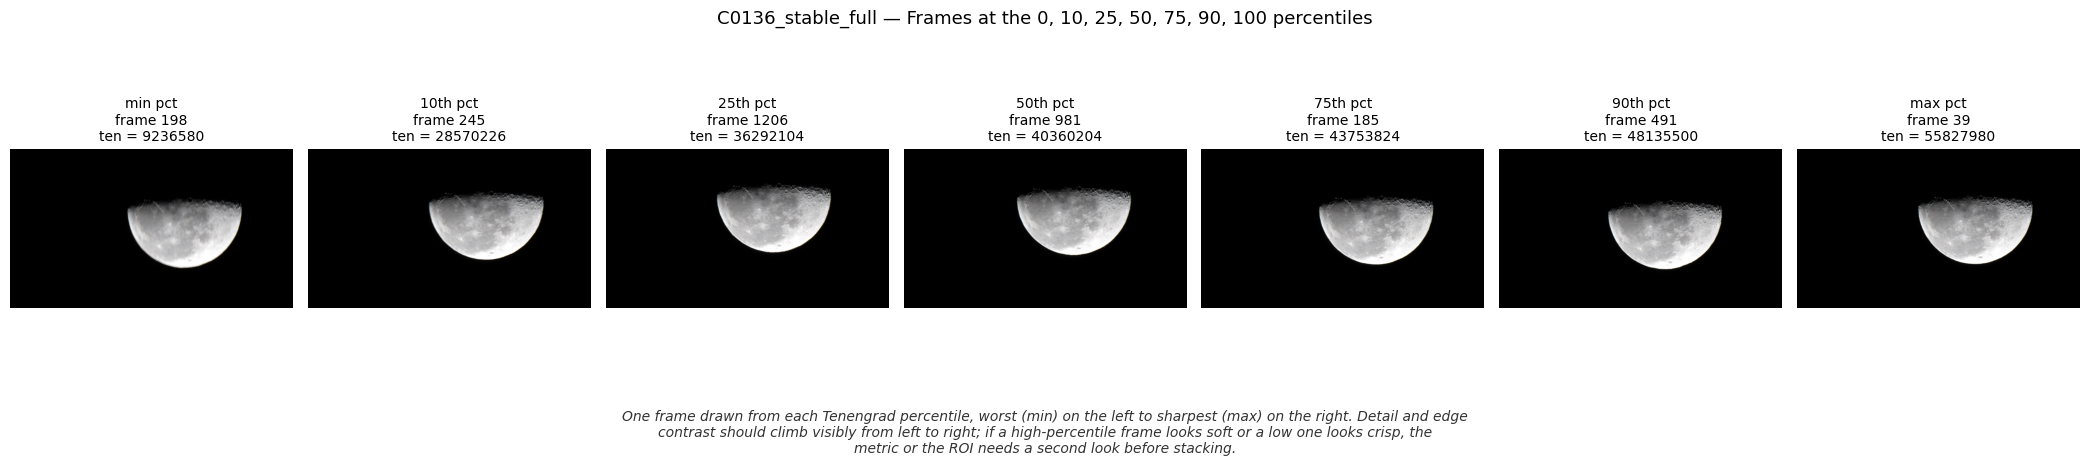

In [7]:
# finding the frame nearest each requested percentile
gallery_rows    = [(quality_df['percentile'] - p).abs().idxmin() for p in gallery_percentiles]
gallery_indices = [int(quality_df.loc[r, 'frame_index']) for r in gallery_rows]
gallery_frames  = read_frames_by_index(path = working_path, wanted_indices = gallery_indices)

fig, panels = plt.subplots(nrows = 1, ncols = len(gallery_percentiles), figsize = (3 * len(gallery_percentiles), 4))

for panel, pct, row in zip(panels, gallery_percentiles, gallery_rows):
    fidx  = int(quality_df.loc[row, 'frame_index'])
    score = quality_df.loc[row, 'tenengrad']
    label = {0: 'min', 100: 'max'}.get(pct, f'{pct}th')
    panel.imshow(X = to_display(image_16bit = gallery_frames[fidx]))
    panel.set_title(label = f'{label} pct\nframe {fidx}\nten = {score:.0f}', fontsize = 10)
    panel.axis('off')

fig.suptitle(t = f'{working_stem} — Frames at the {", ".join(str(p) for p in gallery_percentiles)} percentiles',
             fontsize = 13)

add_caption(fig, "One frame drawn from each Tenengrad percentile, worst (min) on the left to sharpest (max) on "
                 "the right. Detail and edge contrast should climb visibly from left to right; if a high-percentile "
                 "frame looks soft or a low one looks crisp, the metric or the ROI needs a second look before stacking.")

plt.tight_layout(rect = [0, 0, 1, 0.95])
plt.savefig(fname = f'{working_out}/eda_percentile_gallery.png', dpi = 150, bbox_inches = 'tight')
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h3>Summary Statistics</h3>

A compact table of the per-frame measures, plus the spike and flat-window counts, so the analysis has numbers to go with the plots.

In [8]:
# per-measure summary and the exposure-stability counts
summary_table = frame_df[['red', 'green', 'blue', 'laplacian', 'normalized', 'tenengrad']].describe().T
summary_table = summary_table[['mean', 'std', 'min', '50%', 'max']].rename(columns = {'50%': 'median'})

exposure_counts = pd.DataFrame({
    'metric' : ['frames', 'spike frames (>±%.0fσ)' % spike_sigma, 'flat-window frames (±1σ all channels)'],
    'value'  : [len(frame_df), int(spike_mask.sum()), int(frame_df['flat_window'].sum())]})

print("Per-measure summary")
print("-------------------")
display(summary_table.round(2))
print("\nExposure stability")
print("------------------")
display(exposure_counts)

Per-measure summary
-------------------


,mean,std,min,median,max
red,5104.53,21.37,5014.22,5104.94,5224.27
green,5085.05,22.42,4985.45,5085.94,5204.29
blue,5107.00,23.12,5006.56,5108.05,5227.58
laplacian,2.61,0.60,0.55,2.71,3.92
normalized,4.33,0.02,4.18,4.33,4.36
tenengrad,39332360.00,7591724.50,9236580.00,40361060.00,55827980.00



Exposure stability
------------------


,metric,value
0,frames,1320
1,spike frames (>±2σ),109
2,flat-window frames (±1σ all channels),1092


<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Frame Extraction</h2>

The kept frames are written to a <code>tmp_frames</code> folder in the working directory as 16-bit RGB TIFs, one file per frame. Frames flagged as spikes in the exposure trace are dropped here, so only steady frames are exported. Each frame carries a stable <strong>frame_id</strong> (the clip stem plus its zero-padded capture index), and the analysis table is saved beside the frames as <code>frame_analysis.csv</code>. The <strong>frame_id</strong> is the key later notebooks use to update this table in place.

In [ ]:
# a folder in the working directory for the extracted frames and their analysis table
tmp_dir = 'tmp_frames'
os.makedirs(name = tmp_dir, exist_ok = True)


# a stable frame_id per frame, then the spike and keep flags from the exposure analysis
frame_df['frame_id'] = [f'{working_stem}_{index:06d}' for index in frame_df['frame_index']]
frame_df['spike']    = spike_mask
frame_df['kept']     = ~spike_mask


# carrying the sharpness percentile back onto capture order
frame_df = frame_df.merge(right = quality_df[['frame_index', 'percentile']],
                          on    = 'frame_index',
                          how   = 'left')


# writing every non-spike frame to disk as a 16-bit rgb tif, keyed by frame_id
kept_index = set(frame_df.loc[frame_df['kept'], 'frame_index'])
frame_path = {}

extract_capture = cv2.VideoCapture(filename = working_path)
index           = 0

with tqdm(total = frame_total, desc = f'{working_stem}: extracting') as progress:
    while True:
        ok, bgr = extract_capture.read()
        if not ok:
            break
        if index in kept_index:
            frame_id  = f'{working_stem}_{index:06d}'
            save_path = os.path.join(tmp_dir, f'{frame_id}.tif')
            tiff.imwrite(save_path, to_rgb16(frame_bgr = bgr))
            frame_path[index] = save_path
        index += 1
        progress.update(n = 1)
extract_capture.release()


# recording each kept frame's path, then keeping only the exported rows
frame_df['frame_path'] = frame_df['frame_index'].map(frame_path)
frame_analysis         = frame_df[frame_df['kept']].reset_index(drop = True)


# leading with the identity columns other notebooks join on, then saving the table
lead_cols      = ['frame_id', 'frame_index', 'frame_path', 'kept', 'spike']
frame_analysis = frame_analysis[lead_cols + [c for c in frame_analysis.columns if c not in lead_cols]]

analysis_path = os.path.join(tmp_dir, 'frame_analysis.csv')
frame_analysis.to_csv(path_or_buf = analysis_path, index = False)


print(f"""
Frame Extraction
----------------
kept frames : {len(frame_analysis)}
spikes      : {int(frame_df['spike'].sum())}
folder      : {tmp_dir}
table       : {analysis_path}""")